# How to fit an SDSS spectra using BESTA

In this tutorial you will learn how to fit an SDSS fibre spectra of a nearby galaxy

## Data preparation

In [39]:
import numpy as np



from matplotlib import pyplot as plt



from astropy import units as u

Load the spectra

In [40]:
from astropy.io import fits

hdul = fits.open("spec-2240-53823-0178.fits")

In [41]:
print(hdul.info())

print("\n\nCOADD extension column names:", hdul[1].data.names)

Filename: spec-2240-53823-0178.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     141   ()      
  1  COADD         1 BinTableHDU     26   3831R x 8C   [E, E, E, J, J, E, E, E]   
  2  SPECOBJ       1 BinTableHDU    262   1R x 126C   [6A, 4A, 16A, 23A, 16A, 8A, E, E, E, J, E, E, J, B, B, B, B, B, B, J, 22A, 19A, 19A, 22A, 19A, I, 3A, 3A, 1A, J, D, D, D, E, E, 19A, 8A, J, J, J, J, K, K, J, J, J, J, J, J, K, K, K, K, I, J, J, J, J, 5J, D, D, 6A, 21A, E, E, E, J, E, 24A, 10J, J, 10E, E, E, E, E, E, E, J, E, E, E, J, E, 5E, E, 10E, 10E, 10E, 5E, 5E, 5E, 5E, 5E, J, J, E, E, E, E, E, E, 25A, 21A, 10A, E, E, E, E, E, E, E, E, J, E, E, J, 1A, 1A, E, E, J, J, 1A, 5E, 5E]   
  3  SPZLINE       1 BinTableHDU     48   29R x 19C   [J, J, J, 13A, D, E, E, E, E, E, E, E, E, E, E, J, J, E, E]   
None


COADD extension column names: ['flux', 'loglam', 'ivar', 'and_mask', 'or_mask', 'wdisp', 'sky', 'model']


In [42]:
# wavelength
wl = 10**(hdul[1].data["loglam"])
# flux
flux = hdul[1].data["flux"]
# inverse variance
ivar = hdul[1].data["ivar"]

redshift = hdul[2].data["Z"][0]

bad_pixel = (ivar < 0) | ~np.isfinite(flux)
flux_err = np.where(~bad_pixel, 1 / ivar**0.5, np.nan)

wl *= u.Angstrom
flux = flux * 1e-16 * u.erg / (u.s * u.cm**2 * u.Angstrom)
flux_err = flux_err * 1e-16 * flux.unit

spectra_file = "sdss_spectrum.txt"
np.savetxt(spectra_file, np.column_stack([wl.value, flux.value, flux_err.value]),
           header="wavelength(Angstrom) flux(erg/s/cm^2/Angstrom) flux_error(erg/s/cm^2/Angstrom)")

/tmp/ipykernel_40717/4275803004.py:11: RuntimeWarning: divide by zero encountered in divide
  flux_err = np.where(~bad_pixel, 1 / ivar**0.5, np.nan)


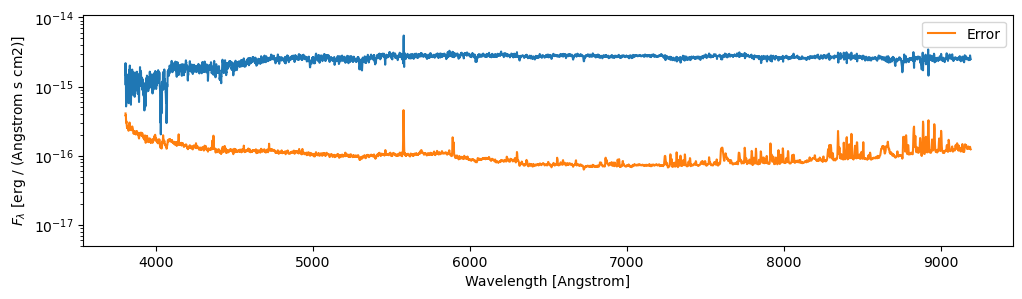

In [43]:
plt.figure(figsize=(12, 3))
plt.plot(wl, flux)
plt.plot(wl, flux_err, label="Error")
plt.xlabel(f"Wavelength [{wl.unit}]")
plt.ylabel(f"$F_\lambda$ [{flux.unit}]")
plt.ylim(5e-18, flux.value.max() * 2)
plt.yscale("log")
plt.legend()

### Data Masking 

BESTA allows users to provide an additional file containing an array of weights used to include in the likelihood estimation. When the weights are binary (i.e. taking values of 0 or 1), this file acts as a mask.

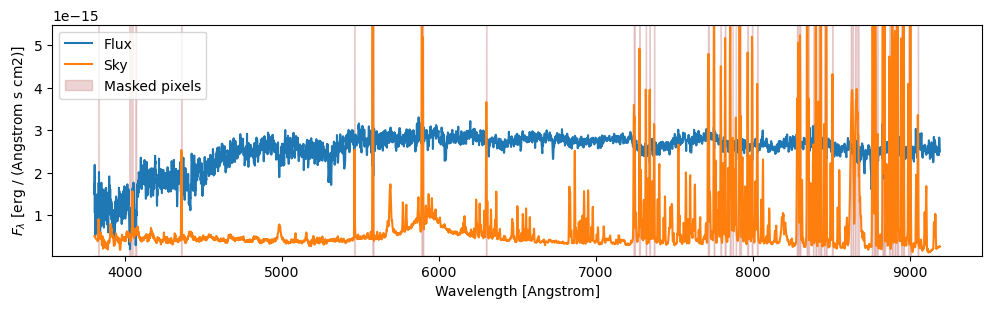

In [44]:
sky = hdul[1].data["sky"] * 1e-16

# Pixels where the flux is below the sky continuum are masked
mask = (flux.value > sky).astype(float)

mask_file = "mask.txt"
np.savetxt(mask_file, mask, header="mask (1 for good pixels, 0 for masked pixels)")

plt.figure(figsize=(12, 3))
plt.plot(wl, flux, label="Flux")
plt.plot(wl, sky, label="Sky")
plt.fill_between(wl.value, 5e-17, (1 - mask) * flux.value.max(),
                 alpha=0.2, color="brown", label="Masked pixels")
plt.xlabel(f"Wavelength [{wl.unit}]")
plt.ylabel(f"$F_\lambda$ [{flux.unit}]")
plt.ylim(5e-17, flux.value.max())
plt.legend()



In addition, BESTA already provides some automatic tools for masking several features:

- masking emission lines
- masking regions contaminated by telluric absorption

## Line Spread Function modelling

IF we are interested in also modelling the line-of-sight velocity distribution of the stellar populations, it is highly recommended to provided at least the LSF of the instrument used. In addition, it is also advisable to include the LSF of the SSP models when these are empirical (e.g. E-MILES)

At the moment BESTA only supports Gaussian LSFs, and it expects the input file to contain at least two columns, where the first two columns are:

- Wavelength array (not necessarily at the same resolution as the input spectra) in Angstrom.
- The FWHM of the LSF at each wavelength bin in Angstrom.

To convert from resolving power, R, to FWHM you can use this expression:  $R(\lambda)=\frac{\lambda}{\rm FWHM(\lambda)}$

**Note that the SSP LSF FWHM must always be lower or the same than the instrumental one.**

Text(0, 0.5, 'FWHM [Angstrom]')

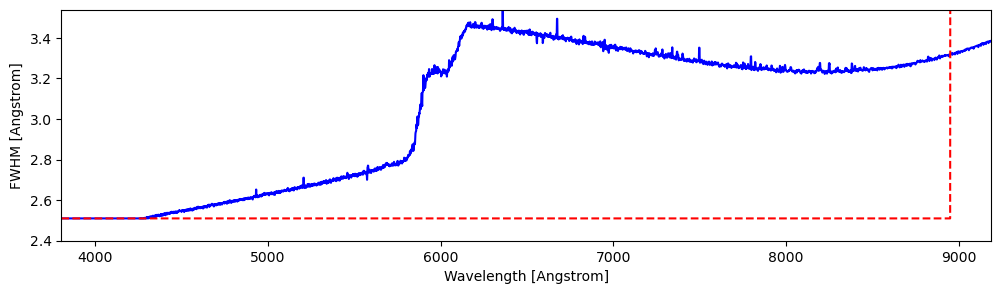

In [45]:
sdss_lsf_file = "lsf_SDSS.dat"
emiles_lsf_file = "e-miles_spectral_resolution.dat"
sdss_lsf_wl, sdss_lsf_fwhm = np.loadtxt(sdss_lsf_file, unpack=True)
emiles_lsf_wl, emiles_lsf_fwhm = np.loadtxt(emiles_lsf_file, unpack=True, usecols=(0, 1))

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(sdss_lsf_wl, sdss_lsf_fwhm, color="b")
ax.plot(emiles_lsf_wl, emiles_lsf_fwhm, color="r", ls="--")

ax.set_xlim(sdss_lsf_wl.min(), sdss_lsf_wl.max())
ax.set_ylim(2.4, sdss_lsf_fwhm.max())
ax.set_xlabel(f"Wavelength [Angstrom]")
ax.set_ylabel("FWHM [Angstrom]")



Based on the plot above, we can only use this SSP models to fit SDSS spectra up to ~8900 $\AA$

## Model preparation

First we have to select a SFH model to fit our spectra. In this case we will use a "non-parametric" SFH model that describes the mass formation history of galaxies as a piece-wise function with fixed bins in the cumulative mass fraction.

In [46]:
from besta.sfh import FixedMassFracSFH

# Obtain the API documentation of this model
FixedMassFracSFH?

Init signature: FixedMassFracSFH(mass_fraction, *args, **kwargs)
Docstring:     
A SFH model with fixed mass fraction bins.

Description
-----------
The SFH of a galaxy is modelled as a stepwise function where the free
parameters correspond to the time at which a given fraction of the total stellar mass was
formed.

Attributes
----------
mass_fractions : np.ndarray
    SFH mass fractions.
lookback_time : astropy.units.Quantity
    Lookback time bin edges.
File:           ~/Develop/besta/src/besta/sfh.py
Type:           ABCMeta
Subclasses:     

Now we define the mass fractions that will be used to fit the cosmic times at which such mass was reached. In this example we will define the 30, 50, 90 and 99 per cent of the total mass at the time of the observation.

Note that the more fractions we use, the more free parameters the model will have. While this provides higher flexibility, it also comes at the price of requiring larger sampling times.

In [47]:
mass_frac = [0.3, 0.5, 0.90, 0.99]

### Priors

Next we will setup the file describing the priors of the model parameters


#### SFH models priors

It is recommended to start with the priors of the SFH model and use the built-in method for generating a prior file that we can update later on

In [48]:
sfh_model = FixedMassFracSFH(mass_frac)

prior_filename = "prior_fixed_mass_frac_sfh.ini"
sfh_model.make_ini(prior_filename)

Now you should find a file in the current working directory. Let's have a look at its contents

In [49]:
with open(prior_filename, "r") as f:
    print("Contents of the generated INI file:")
    print("***********************************")
    print(f.read())
    print("***********************************")

Contents of the generated INI file:
***********************************
[stars.sfh]
alpha_powerlaw = 0 0.5 3
ism_metallicity_today = 0.005 0.01 0.08
t_at_frac_0.3000 = 0 4.118369897597358 13.72789965865786
t_at_frac_0.5000 = 0 6.86394982932893 13.72789965865786
t_at_frac_0.9000 = 0 12.355109692792073 13.72789965865786
t_at_frac_0.9900 = 0 13.59062066207128 13.72789965865786

***********************************


Ini files work in sections, denoted  by square brackets "[ ]". In this case we only have one section, the one corresponding to our SFH model ``[stars.sfh]``.

Inside this section you will find all the free parameters of this SFH model:

- ``alpha_powerlaw``
- ``ism_metallicity_today``
- ``t_at_frac_***``

The first two free parameters control the chemical enrichment of the stellar population following:

$$Z_{\rm ISM}(t) = Z_{\rm ISM,\,today} \left(\frac{M_*(t)}{M_*(\rm today)}\right)^\alpha$$

Note that "today" does not refer to our present time, but to the time when the model stops (i.e. the time of observation).

The remaning parameters are the times at which $M_*(t)$ reached a given fraction of the present stellar mass.

For each parameter, by default you will find three numbers. These correspond to the left-most, central, and right-most points of a top-hat prior distribution, respectively. Values outside this range will have null probability. The current default for this model is to assume a constant SFH, so 30% of the total stellar mass is reached with the Universe is 30% as old as at the time of observation.

While "uninformative" priors are the most common choice, users can define alternative priors (e.g. Gaussian, exponential) following the [CosmoSIS documentation](https://cosmosis.readthedocs.io/en/latest/usage/parameter_files.html).




#### Stellar Kinematics

Now we are going to include an additional set of parameters in our previously created ini file to track the stellar kinematics and the broadening and shift of the absorption features.

The stellar kinematics are stored in a section named ``[kinematics]``. At the moment, the only available LOSVD model is a Gaussian Hermite, see e.g. [Capellari 2016](https://arxiv.org/abs/1607.08538), and the free parameters are

- Mean velocity (km/s): ``los_vel``
- Velocity dispersion (km/s): ``los_sigma``
- Hermite coefficients: ``los_h3`` and ``los_h4``

For the purposes of this tutorial, we will set free the first two while we will set to 0 the Hermite coefficients (i.e. assuming a perfect Gaussian LOSVD). To fix a parameter in the INI file simply set it equal to a single number.

In [50]:
new_sections = """[kinematics]
los_vel = -500 0 500
los_sigma = 10 100 300
los_h3 = 0
los_h4 = 0
"""

# Now we append the new sections to the existing INI file
with open(prior_filename, "a") as f:
    f.write(new_sections)

### Dust extinction

We will also include a simple dust-screen attenuation model. In the current BESTA implementation, setting `ExtinctionLaw` in the module configuration activates a `dust.extinction` section in the values file, where `a_v` is the free parameter controlling the visual attenuation.



For this tutorial we keep the model minimal and fit only `a_v`. If you want to disable dust attenuation entirely, remove both the `dust.extinction` section from the values file and the `ExtinctionLaw` entry from the module configuration.

In [51]:
new_sections = """[dust.extinction]
a_v = 0 0.3 2.0
"""

# Now we append the new sections to the existing INI file
with open(prior_filename, "a") as f:
    f.write(new_sections)

## Model fitting



Now we combine the data products and priors prepared above into the configuration dictionary that BESTA will pass to `MainPipeline`.



`MainPipeline` writes the corresponding CosmoSIS `.ini` and `values` files for you and then runs the requested samplers. Even for a single-module fit, the configuration is organized in the same sections used by a regular CosmoSIS parameter file.



The configuration should always include the following top-level sections:



- **`runtime`**

  Selects the sampler sequence. In this tutorial we use `maxlike emcee`, which means BESTA first runs a deterministic maximum-likelihood search and then starts an `emcee` chain from that region of parameter space.



- **sampler-specific sections**

  Each sampler listed in `runtime["sampler"]` needs its own configuration block. Here that means a `maxlike` section, with the optimizer settings, and an `emcee` section, with the number of walkers and samples.



- **`output`**

  Controls where CosmoSIS writes the chain and in which format. `Reader.from_results_file(...)` expects the text output generated here.



- **`pipeline`**

  Declares which modules are executed, which values file contains the priors, which likelihood names should be stored, and any optional diagnostics such as `timing`, `debug`, or `extra_output`.



More information on the underlying file format is available in the [CosmoSIS parameter file documentation](https://cosmosis.readthedocs.io/en/latest/usage/parameter_files/params_ini.html).



In addition, we must provide the configuration for the fitting module itself. In this tutorial we use `FullSpectralFitModule`, which fits the stellar population history and line-of-sight kinematics directly from the observed spectrum.



Required and commonly used options for `FullSpectralFitModule`:


- **`file`**: path to the Python module that CosmoSIS should load. For BESTA modules, use `MyModule.get_path()`.

- **`inputSpectrum`**: text file with wavelength, flux, and flux uncertainty.

Optional data-handling options:

- **`velscale`**: logarithmic velocity spacing, in km/s, used when rebinding both the observed spectrum and the SSP templates.

- **`wlRange`**: rest-frame wavelength interval to include in the fit.

- **`redshift`**: source redshift used to move the observed spectrum to the rest frame.

- **`mask`**: path to the weights or mask file created above.

- **`lsf`**: instrumental line-spread-function file for the observed spectrum.

- **`fluxUnits`**: units of the input flux columns. The default is `1e-16 erg / (s cm2 Angstrom)`.

- **`wlUnits`**: units of the wavelength column. The default is `Angstrom`.

- **`mask_telluric`** and **`telluric_pad`**: enable masking of atmospheric bands, with an optional padding width.

- **`mask_emission_lines`**: automatically mask strong nebular emission lines before evaluating the likelihood.



Stellar-population model options:



- **`SSPModel`**: SSP family used to generate the templates.

- **`SSPModelArgs`**: comma-separated constructor arguments for the SSP model.

- **`SSPDir`**: optional path to the SSP library when it is not discovered automatically.

- **`SSPLSF`**: optional LSF file for the SSP library. BESTA uses it together with the observed LSF to compute the effective convolution kernel.

- **`SaveSSPModel`** or **`SSPModelFromPickle`**: optional cache helpers to avoid rebuilding the template library repeatedly when fitting multiple spectra (with common LSF).


Star-formation-history and continuum options:

- **`SFHModel`**: name of the SFH model class.

- **`SFHArgs1`, `SFHArgs2`, ...**: positional arguments passed to that SFH model.

- **`ExtinctionLaw`**: extinction law used by the dust screen. With this option enabled, the values file must include the `dust.extinction` section we created above.

- **`legendre_deg`**: optional multiplicative Legendre-polynomial degree used to absorb low-order continuum-shape mismatches. More details can be found [here](https://besta.readthedocs.io/en/latest/configuration.html#multiplicative-polynomials).



For this tutorial, the values file is the `prior_filename` generated and extended in the previous cells.

In [52]:
from besta import MainPipeline, Reader
from besta.pipeline_modules.full_spectral_fit import FullSpectralFitModule

In [53]:
configuration = {

    # Sampling strategy

    "runtime": {"sampler": "maxlike emcee"},

    "maxlike": {

        "method": "Nelder-Mead",
        "tolerance": 1e-3,
        "maxiter": 5000,
        "repeats": 5,
        "start_method": "prior",
    },
    "emcee": {"walkers": 64, "samples": 100, "nsteps": 100},

    # Output configuration
    "output": {"filename": "results_sdss_tutorial.txt", "format": "text"},

    # Pipeline configuration
    "pipeline": {
        "modules": "FullSpectralFit",   # This name is arbitrary identifier for the module, not necessarily the same as the class name
        "values": prior_filename,
        "likelihoods": "FullSpectralFit",
        "timing": "T",
        "debug": "T",
        "extra_output": "extra/stellar_mass",
    },

    # Module-specific configuration

    "FullSpectralFit": {
        "file": FullSpectralFitModule.get_path(),
        "inputSpectrum": spectra_file,
        "fluxUnits": "erg/ (s cm^2 Angstrom)",
        "wlRange": [3800.0, 7500.0],
        "redshift": redshift,
        "mask": mask_file,
        "lsf": sdss_lsf_file,
        ## SSP model configuration
        "SSPModel": "EMILES",
        "SSPModelArgs": "PADOVA00,KROUPA_UNIVERSAL",
        # "SSPDir": "/path/to/SSP_TEMPLATES/EMILES",
        "SSPLSF": emiles_lsf_file,
        # "SaveSSPModel": "SSPModel_EMILES.pkl",
        # "SSPModelFromPickle": "SSPModel_EMILES.pkl",

        ## SFH model configuration
        "SFHModel": "FixedMassFracSFH",
        "SFHArgs1": "0.3, 0.5, 0.9, 0.99",
        ## Additional configuration for kinematics and extinction
        "velscale": 90.0,
        "ExtinctionLaw": "ccm89",
    },
}



configuration

{'runtime': {'sampler': 'maxlike emcee'},
 'maxlike': {'method': 'Nelder-Mead',
  'tolerance': 0.001,
  'maxiter': 5000,
  'repeats': 5,
  'start_method': 'prior'},
 'emcee': {'walkers': 64, 'samples': 100, 'nsteps': 100},
 'output': {'filename': 'results_sdss_tutorial.txt', 'format': 'text'},
 'pipeline': {'modules': 'FullSpectralFit',
  'values': 'prior_fixed_mass_frac_sfh.ini',
  'likelihoods': 'FullSpectralFit',
  'timing': 'T',
  'debug': 'T',
  'extra_output': 'extra/stellar_mass'},
 'FullSpectralFit': {'file': '/home/pcorchoc/Develop/besta/src/besta/pipeline_modules/full_spectral_fit.py',
  'inputSpectrum': 'sdss_spectrum.txt',
  'fluxUnits': 'erg/ (s cm^2 Angstrom)',
  'wlRange': [3800.0, 7500.0],
  'redshift': 0.024784192,
  'mask': 'mask.txt',
  'lsf': 'lsf_SDSS.dat',
  'SSPModel': 'EMILES',
  'SSPModelArgs': 'PADOVA00,KROUPA_UNIVERSAL',
  'SSPLSF': 'e-miles_spectral_resolution.dat',
  'SFHModel': 'FixedMassFracSFH',
  'SFHArgs1': '0.3, 0.5, 0.9, 0.99',
  'velscale': 90.0,
  

### Running the fit



At this point all ingredients are in place: the observed spectrum, the mask, the instrumental and SSP LSF files, and the values file containing the free parameters and priors. The next cell instantiates `MainPipeline` with a single configuration and launches the CosmoSIS run.



`MainPipeline` will:



1. generate the temporary CosmoSIS `.ini` file for this configuration,

2. reuse the `prior_filename` values file we prepared above,

3. run the samplers listed in `runtime["sampler"]`, and

4. if `plot_result=True`, reconstruct the maximum-posterior solution and save a best-fit figure next to the output chain.



For this tutorial the main text output is written to `results_sdss_tutorial.txt`. Depending on the machine and on the sampler settings, this step can take from seconds to several minutes. If you are testing the workflow first, it is often useful to keep the `emcee` settings modest and then increase them once the configuration runs successfully.

In [ ]:
main_pipe = MainPipeline([configuration])
main_pipe.execute_all(plot_result=True)

File containing the .ini priors already exists at prior_fixed_mass_frac_sfh.ini


Setting up pipeline from parameter file FullSpectralFit_auto.ini
----------------------------------------------------------------

Setting up module FullSpectralFit
----------------------------------
> Initialising E-MILES models (IMF=KROUPA_UNIVERSAL, ISO=PADOVA00)
[SSP] Interpolating SSP SEDs
Setup all pipeline modules

Module timing:
FullSpectralFit 0.543319

Parameter Priors
----------------
stars.sfh--alpha_powerlaw         ~ U(0.0, 3.0)
stars.sfh--ism_metallicity_today  ~ U(0.005, 0.08)
stars.sfh--t_at_frac_0.3000       ~ U(0.0, 13.72789965865786)
stars.sfh--t_at_frac_0.5000       ~ U(0.0, 13.72789965865786)
stars.sfh--t_at_frac_0.9000       ~ U(0.0, 13.72789965865786)
stars.sfh--t_at_frac_0.9900       ~ U(0.0, 13.72789965865786)
kinematics--los_vel               ~ U(-500.0, 500.0)
kinematics--los_sigma             ~ U(10.0, 300.0)
kinematics--los_h3                ~ delta(0)
kinematics--los_h4                ~ delta(0)
dust.extinction--a_v              ~ U(0.0, 2.0)

***********

# Reading the results



After the run finishes, CosmoSIS writes the sampled chain to the file specified in `configuration["output"]["filename"]`. BESTA also stores a copy of the parameter-file header inside that text file, so `Reader.from_results_file(...)` can reconstruct the module configuration without needing the generated `.ini` file.



A typical post-processing workflow is:



1. build a `Reader` from the results file,

2. call `load_results()` to read the chain into an Astropy table,

3. inspect the available columns and number of samples, and

4. extract the maximum-posterior or maximum-likelihood solution for further analysis.



The `Reader` object can also reconstruct a module instance from the stored configuration, which is useful if you want to re-evaluate the best-fit model or make your own diagnostic plots after the sampler finishes.

In [ ]:
from besta import Reader
reader = Reader.from_results_file("results_sdss_tutorial.txt")

reader.load_results()

print(f"Loaded {len(reader.results_table)} samples")
print("Available columns:")
print(reader.results_table.colnames)

best_fit = reader.get_maxlike_solution()

print("Maximum likelihood solution:")
print(best_fit)

## Post-processing



Once the chain has been loaded, BESTA provides a lightweight post-processing layer to summarize the posterior and generate diagnostic plots. In the cells below we use `summarize_results(...)` to build a `ResultsSummary` object directly from `reader.results_table`.



This summary object stores:



- posterior weights derived from the `post` column,

- the maximum-posterior and weighted-mean parameter estimates,

- covariance and correlation matrices,

- one-dimensional posterior PDFs for all sampled parameters, and

- optional two-dimensional PDFs for the specific parameter pairs requested in `parameter_key_pairs`.



In this example we ask for two 2D posterior projections:



- `kinematics--los_vel` versus `kinematics--los_sigma`, and

- `dust.extinction--a_v` versus `stars.sfh--t_at_frac_0.9900`.



The final cell uses convenience methods on the `ResultsSummary` object to save a corner plot and the 2D posterior-density plots to disk. If you want additional diagnostics, the same `reader.results_table` can also be passed to `plot_chains(...)` to inspect trace plots of the sampled parameters.

In [ ]:
from besta.postprocess import plot_chains, summarize_results

summary = summarize_results(reader.results_table, compute_2d=True,
                            parameter_key_pairs=[("kinematics--los_vel", "kinematics--los_sigma"),
                                                 ("dust.extinction--a_v", "stars.sfh--t_at_frac_0.9900")])

In [ ]:
summary.corner_plot(outpath="./corner_plot.png")
summary.plot_2d_pdfs(outdir="./2d_pdfs")